In [1]:
# **Importing Libraries**
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set()

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from imblearn.over_sampling import SMOTE

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.model_selection import StratifiedKFold, GridSearchCV

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.metrics import make_scorer, recall_score, precision_recall_curve, average_precision_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from sklearn.calibration import CalibratedClassifierCV
from tensorflow.keras.losses import BinaryFocalCrossentropy
from scikeras.wrappers import KerasClassifier

from sklearn.metrics import fbeta_score

In [2]:
# **Importing Dataset**
data = pd.read_csv('/Users/alfonsoqu/Desktop/ASU/2025Summer/DAT 490/cleaned_dataset.csv')

print("Dataset shape:", data.shape)
print("\nColumn names:")
print(data.columns.tolist())
print("\nFirst few rows:")
data.head()

Dataset shape: (111717, 41)

Column names:
['order_id', 'order_item_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_estimated_delivery_date', 'is_canceled', 'customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'customer_lat', 'customer_lng', 'order_delivered_customer_date', 'is_first_time_buyer', 'seller_id', 'seller_zip_code_prefix', 'seller_city', 'seller_state', 'seller_lat', 'seller_lng', 'shipping_limit_date', 'order_delivered_carrier_date', 'handoff_delay', 'distance_km', 'product_id', 'product_category_name_english', 'price', 'freight_value', 'product_name_length', 'product_description_length', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'review_id', 'review_score', 'delivered_late', 'delivery_delay']

First few rows:


,order_id,order_item_id,order_status,order_purchase_timestamp,order_approved_at,order_estimated_delivery_date,is_canceled,customer_id,customer_unique_id,customer_zip_code_prefix,...,product_description_length,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,review_id,review_score,delivered_late,delivery_delay
0,e481f51cbdc54678b7cc49136f2d6af7,1.0,delivered,2017-10-02,2017-10-02,2017-10-18,False,9ef432eb6251297304e76186b10a928d,7c396fd4830fd04220f754e42b4e5bff,3149,...,268.0,4.0,500.0,19.0,8.0,13.0,a54f0611adc9ed256b57ede6b6eb5114,4.0,False,-8.0
1,53cdb2fc8bc7dce0b6741e2150273451,1.0,delivered,2018-07-24,2018-07-26,2018-08-13,False,b0830fb4747a6c6d20dea0b8c802d7ef,af07308b275d755c9edb36a90c618231,47813,...,178.0,1.0,400.0,19.0,13.0,19.0,8d5266042046a06655c8db133d120ba5,4.0,False,-6.0
2,47770eb9100c2d0c44946d9cf07ec65d,1.0,delivered,2018-08-08,2018-08-08,2018-09-04,False,41ce2a54c0b03bf3443c3d931a367089,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,232.0,1.0,420.0,24.0,19.0,21.0,e73b67b67587f7644d5bd1a52deb1b01,5.0,False,-18.0
3,949d5b44dbf5de918fe9c16f97b45f8a,1.0,delivered,2017-11-18,2017-11-18,2017-12-15,False,f88197465ea7920adcdbec7375364d82,7c142cf63193a1473d2e66489a9ae977,59296,...,468.0,3.0,450.0,30.0,10.0,20.0,359d03e676b3c069f62cadba8dd3f6e8,5.0,False,-13.0
4,ad21c59c0840e6cb83a9ceb5573f8159,1.0,delivered,2018-02-13,2018-02-13,2018-02-26,False,8ab97904e6daea8866dbdbc4fb7aad2c,72632f0f9dd73dfee390c9b22eb56dd6,9195,...,316.0,4.0,250.0,51.0,15.0,15.0,e50934924e227544ba8246aeb3770dd4,5.0,False,-10.0


In [3]:
# **Data Exploration**
print("\nTarget variable distribution:")
print(data['is_canceled'].value_counts())
print("\nFirst-time buyer distribution:")
print(data['is_first_time_buyer'].value_counts())


Target variable distribution:
is_canceled
False    111191
True        526
Name: count, dtype: int64

First-time buyer distribution:
is_first_time_buyer
True     84451
False    27266
Name: count, dtype: int64


In [4]:
# **Pre-Processing**
# **Removing Unnecessary Columns**
# Keep relevant features for cancellation prediction and customer segmentation
data_processed = data.drop(columns=[
    'order_id',
    'order_item_id',
    'order_status',
    'order_purchase_timestamp',
    'order_approved_at',
    'order_estimated_delivery_date',
    'customer_id',
    'customer_unique_id',
    'customer_zip_code_prefix',
    'customer_lat',
    'customer_lng',
    'order_delivered_customer_date',
    'seller_zip_code_prefix',
    'seller_lat',
    'seller_lng',
    'shipping_limit_date',
    'order_delivered_carrier_date',
    'product_id',
    'review_id',
    'delivered_late',
    'delivery_delay',
    'review_score'
]).copy()

print("Data shape after column removal:", data_processed.shape)
print("\nRemaining columns:")
print(data_processed.columns.tolist())

Data shape after column removal: (111717, 19)

Remaining columns:
['is_canceled', 'customer_city', 'customer_state', 'is_first_time_buyer', 'seller_id', 'seller_city', 'seller_state', 'handoff_delay', 'distance_km', 'product_category_name_english', 'price', 'freight_value', 'product_name_length', 'product_description_length', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']


In [5]:
# **Removing NA Rows**
print("Missing values before cleaning:")
print(data_processed.isnull().sum())

data_processed = data_processed.dropna()
print("\nData shape after removing NA rows:", data_processed.shape)

Missing values before cleaning:
is_canceled                         0
customer_city                       0
customer_state                      0
is_first_time_buyer                 0
seller_id                           0
seller_city                         0
seller_state                        0
handoff_delay                    1161
distance_km                         0
product_category_name_english    1613
price                               0
freight_value                       0
product_name_length              1589
product_description_length       1589
product_photos_qty               1589
product_weight_g                   17
product_length_cm                  17
product_height_cm                  17
product_width_cm                   17
dtype: int64

Data shape after removing NA rows: (108983, 19)


In [6]:
# **Variable Selection**
# Target variable: is_canceled
# Keep is_first_time_buyer for segmentation analysis
X = data_processed.drop(columns=['is_canceled'])
y = data_processed['is_canceled']

print("Features for modeling:")
print(X.columns.tolist())
print(f"\nTarget variable distribution:")
print(y.value_counts())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

Features for modeling:
['customer_city', 'customer_state', 'is_first_time_buyer', 'seller_id', 'seller_city', 'seller_state', 'handoff_delay', 'distance_km', 'product_category_name_english', 'price', 'freight_value', 'product_name_length', 'product_description_length', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']

Target variable distribution:
is_canceled
False    108908
True         75
Name: count, dtype: int64


In [7]:
# **Encoding Variables**
# Define categorical and numerical features
categorical_features = [
    'customer_city',
    'customer_state',
    'seller_city',
    'seller_state',
    'seller_id',
    'product_category_name_english',
    'is_first_time_buyer',  # Include for segmentation
    'delivered_late'
]

numerical_features = [
    'handoff_delay',
    'distance_km',
    'price',
    'freight_value',
    'product_name_length',
    'product_description_length',
    'product_photos_qty',
    'product_weight_g',
    'product_length_cm',
    'product_height_cm',
    'product_width_cm',
    'review_score',
    'delivery_delay'
]

# Filter features that actually exist in the dataset
existing_categorical = [col for col in categorical_features if col in X.columns]
existing_numerical = [col for col in numerical_features if col in X.columns]

print("Categorical features to encode:", existing_categorical)
print("Numerical features to scale:", existing_numerical)

preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=True), existing_categorical),
    ('num', StandardScaler(), existing_numerical)
])

# Transform
X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

Categorical features to encode: ['customer_city', 'customer_state', 'seller_city', 'seller_state', 'seller_id', 'product_category_name_english', 'is_first_time_buyer']
Numerical features to scale: ['handoff_delay', 'distance_km', 'price', 'freight_value', 'product_name_length', 'product_description_length', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']


In [30]:
# Basic counts
print("1. Raw counts:")
print(data['is_canceled'].value_counts())
print()

# Percentages
print("2. Percentages:")
print(data['is_canceled'].value_counts(normalize=True) * 100)
print()

1. Raw counts:
is_canceled
False    111191
True        526
Name: count, dtype: int64

2. Percentages:
is_canceled
False    99.529167
True      0.470833
Name: proportion, dtype: float64



In [32]:
# More detailed breakdown
total_orders = len(data)
canceled_orders = data['is_canceled'].sum()
not_canceled_orders = total_orders - canceled_orders

print("3. Detailed breakdown:")
print(f"Total orders: {total_orders}")
print(f"Canceled orders: {canceled_orders}")
print(f"Not canceled orders: {not_canceled_orders}")
print(f"Cancellation rate: {(canceled_orders/total_orders)*100:.2f}%")
print()

# Check data types to make sure we're reading correctly
print("4. Data type check:")
print(f"is_canceled column type: {data['is_canceled'].dtype}")
print(f"Unique values in is_canceled: {data['is_canceled'].unique()}")
print()

3. Detailed breakdown:
Total orders: 111717
Canceled orders: 526
Not canceled orders: 111191
Cancellation rate: 0.47%

4. Data type check:
is_canceled column type: bool
Unique values in is_canceled: [False  True]



In [33]:
# If the column contains True/False as strings instead of booleans
if data['is_canceled'].dtype == 'object':
    print("5. String value analysis:")
    print(data['is_canceled'].value_counts())
    print("Converting to boolean...")
    data['is_canceled'] = data['is_canceled'].map({'True': True, 'False': False, True: True, False: False})
    print("After conversion:")
    print(data['is_canceled'].value_counts())
    print()

# Cross-check with order_status if available
if 'order_status' in data.columns:
    print("6. Cross-check with order_status:")
    print(data['order_status'].value_counts())
    print()

    # Check relationship between order_status and is_canceled
    print("7. Relationship between order_status and is_canceled:")
    print(pd.crosstab(data['order_status'], data['is_canceled'], margins=True))
    print()

# Check for any patterns by customer type
if 'is_first_time_buyer' in data.columns:
    print("8. Cancellation by customer type:")
    cancellation_by_type = data.groupby('is_first_time_buyer')['is_canceled'].agg(['count', 'sum', 'mean'])
    cancellation_by_type.columns = ['Total Orders', 'Canceled Orders', 'Cancellation Rate']
    print(cancellation_by_type)
    print()

# Sample some canceled orders to verify
if canceled_orders > 0:
    print("9. Sample of canceled orders:")
    canceled_sample = data[data['is_canceled'] == True].head()
    print(canceled_sample[['order_id', 'is_canceled', 'order_status'] if 'order_status' in data.columns else ['order_id', 'is_canceled']])
else:
    print("9. NO CANCELED ORDERS FOUND!")
    print("This explains why your models have AP = 0.00")
    print("Recommendations:")
    print("- Check if 'is_canceled' column is correctly defined")
    print("- Verify data preprocessing steps")
    print("- Consider using a different target variable")
    print("- Collect more data with actual cancellations")

6. Cross-check with order_status:
order_status
delivered      109307
shipped          1174
canceled          526
invoiced          354
processing        346
unavailable         7
approved            3
Name: count, dtype: int64

7. Relationship between order_status and is_canceled:
is_canceled    False  True     All
order_status                      
approved           3     0       3
canceled           0   526     526
delivered     109307     0  109307
invoiced         354     0     354
processing       346     0     346
shipped         1174     0    1174
unavailable        7     0       7
All           111191   526  111717

8. Cancellation by customer type:
                     Total Orders  Canceled Orders  Cancellation Rate
is_first_time_buyer                                                  
False                       27266              134           0.004915
True                        84451              392           0.004642

9. Sample of canceled orders:
                      

In [8]:
# **Getting Feature Names**
if hasattr(X_train_encoded, "toarray"):
    X_train_encoded = X_train_encoded.toarray()
    X_test_encoded = X_test_encoded.toarray()

# Get column names
cat_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(existing_categorical)
all_feature_names = list(cat_feature_names) + existing_numerical

# Convert to DataFrames
X_train_df = pd.DataFrame(X_train_encoded, columns=all_feature_names)
X_test_df = pd.DataFrame(X_test_encoded, columns=all_feature_names)

print("Final feature set shape:", X_train_df.shape)

Final feature set shape: (87186, 7281)


In [9]:
# **Applying SMOTE**
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_df, y_train)

print("After SMOTE - Training set shape:", X_train_resampled.shape)
print("After SMOTE - Target distribution:")
print(pd.Series(y_train_resampled).value_counts())

After SMOTE - Training set shape: (174252, 7281)
After SMOTE - Target distribution:
is_canceled
False    87126
True     87126
Name: count, dtype: int64


In [10]:
# **Applying StratifiedKFold**
stratified_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# **Focusing Recall for the Positive Cancellations**
recall_scorer = make_scorer(recall_score, pos_label=True)

In [11]:
# **Logistic Regression**
# **Creating the Best Model**
# Logistic regression model
log_reg = LogisticRegression(max_iter=1000, solver='liblinear', random_state=42)

# Hyperparameter grid (penalty type and C values)
param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l1', 'l2']  # Try both L1 and L2 regularization
}

# Grid search setup
grid_log_reg = GridSearchCV(
    estimator=log_reg,
    param_grid=param_grid,
    scoring=recall_scorer,
    cv=stratified_cv,
    verbose=2,
    n_jobs=1
)

# Fit model
grid_log_reg.fit(X_train_resampled, y_train_resampled)

# Extract best model and params
best_log_reg = grid_log_reg.best_estimator_
print("Best Parameters:", grid_log_reg.best_params_)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
[CV] END .................................C=0.01, penalty=l1; total time=  28.5s
[CV] END .................................C=0.01, penalty=l1; total time=  27.0s
[CV] END .................................C=0.01, penalty=l1; total time=  27.8s
[CV] END .................................C=0.01, penalty=l1; total time=  27.2s
[CV] END .................................C=0.01, penalty=l1; total time=  28.7s
[CV] END .................................C=0.01, penalty=l2; total time=  25.8s
[CV] END .................................C=0.01, penalty=l2; total time=  25.8s
[CV] END .................................C=0.01, penalty=l2; total time=  26.1s
[CV] END .................................C=0.01, penalty=l2; total time=  25.6s
[CV] END .................................C=0.01, penalty=l2; total time=  26.0s
[CV] END ..................................C=0.1, penalty=l1; total time=  37.5s
[CV] END ..................................C=0.1,

In [12]:
# **Testing the Model**
# Predict probabilities
y_proba_logreg = best_log_reg.predict_proba(X_test_df)[:, 1]
# === Threshold Optimization ===
precision, recall, thresholds = precision_recall_curve(y_test, y_proba_logreg)
f2_scores = 5 * (precision * recall) / (4 * precision + recall + 1e-6)
optimal_threshold_logreg = thresholds[np.argmax(f2_scores)]
print(f"\nOptimal Threshold (LogReg): {optimal_threshold_logreg:.4f}")

# Apply optimal threshold
y_pred_logreg_opt = (y_proba_logreg >= optimal_threshold_logreg).astype(int)


Optimal Threshold (LogReg): 0.8877



Classification Report (Logistic Regression):
              precision    recall  f1-score   support

       False       1.00      0.99      0.99     21782
        True       0.01      0.13      0.02        15

    accuracy                           0.99     21797
   macro avg       0.50      0.56      0.51     21797
weighted avg       1.00      0.99      0.99     21797

ROC-AUC Score: 0.6663


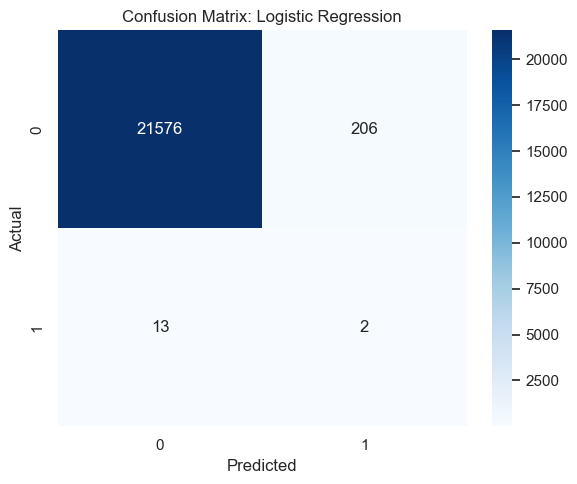

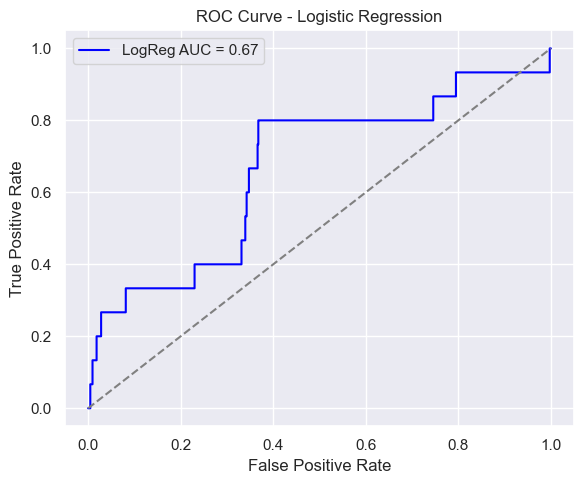

In [13]:
# Metrics
print("\nClassification Report (Logistic Regression):")
print(classification_report(y_test, y_pred_logreg_opt))

roc_auc = roc_auc_score(y_test, y_proba_logreg)
print(f"ROC-AUC Score: {roc_auc:.4f}")

plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_logreg_opt), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix: Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

fpr, tpr, _ = roc_curve(y_test, y_proba_logreg)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"LogReg AUC = {roc_auc:.2f}", color='blue')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.tight_layout()
plt.show()

In [14]:
# **Decision Tree**
# **Creating the Best Model**
# Define the Decision Tree Classifier
tree_clf = DecisionTreeClassifier(random_state=42)

# Define hyperparameter grid
param_grid_tree = {
    'max_depth': [5, 10, 15],
    'min_samples_split': [10, 20],
    'criterion': ['gini', 'entropy']
}

# Grid search
grid_tree = GridSearchCV(
    estimator=tree_clf,
    param_grid=param_grid_tree,
    scoring=recall_scorer,
    cv=stratified_cv,
    verbose=2,
    n_jobs=1
)

# Fit to the resampled training set
grid_tree.fit(X_train_resampled, y_train_resampled)

# Best model and parameters
best_tree = grid_tree.best_estimator_
print("Best Parameters:", grid_tree.best_params_)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
[CV] END ..criterion=gini, max_depth=5, min_samples_split=10; total time=  25.7s
[CV] END ..criterion=gini, max_depth=5, min_samples_split=10; total time=  24.2s
[CV] END ..criterion=gini, max_depth=5, min_samples_split=10; total time=  23.8s
[CV] END ..criterion=gini, max_depth=5, min_samples_split=10; total time=  23.5s
[CV] END ..criterion=gini, max_depth=5, min_samples_split=10; total time=  24.8s
[CV] END ..criterion=gini, max_depth=5, min_samples_split=20; total time=  24.8s
[CV] END ..criterion=gini, max_depth=5, min_samples_split=20; total time=  23.5s
[CV] END ..criterion=gini, max_depth=5, min_samples_split=20; total time=  23.6s
[CV] END ..criterion=gini, max_depth=5, min_samples_split=20; total time=  23.9s
[CV] END ..criterion=gini, max_depth=5, min_samples_split=20; total time=  24.6s
[CV] END .criterion=gini, max_depth=10, min_samples_split=10; total time=  27.9s
[CV] END .criterion=gini, max_depth=10, min_samp

In [15]:
# **Evaluating the Model**
# Predict probabilities
y_proba_tree = best_tree.predict_proba(X_test_df)[:, 1]

# === Threshold Optimization ===
precision_tree, recall_tree, thresholds_tree = precision_recall_curve(y_test, y_proba_tree)
f2_scores_tree = 5 * (precision_tree * recall_tree) / (4 * precision_tree + recall_tree + 1e-6)
optimal_threshold_tree = thresholds_tree[np.argmax(f2_scores_tree)]
print(f"\nOptimal Threshold (Decision Tree): {optimal_threshold_tree:.4f}")

# Apply optimal threshold
y_pred_tree_opt = (y_proba_tree >= optimal_threshold_tree).astype(int)

# Metrics
print("\nClassification Report (Decision Tree):")
print(classification_report(y_test, y_pred_tree_opt))

roc_auc_tree = roc_auc_score(y_test, y_proba_tree)
print(f"ROC-AUC Score (Tree): {roc_auc_tree:.4f}")


Optimal Threshold (Decision Tree): 0.0000

Classification Report (Decision Tree):
              precision    recall  f1-score   support

       False       0.00      0.00      0.00     21782
        True       0.00      1.00      0.00        15

    accuracy                           0.00     21797
   macro avg       0.00      0.50      0.00     21797
weighted avg       0.00      0.00      0.00     21797

ROC-AUC Score (Tree): 0.4894


/Users/alfonsoqu/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/alfonsoqu/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/alfonsoqu/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


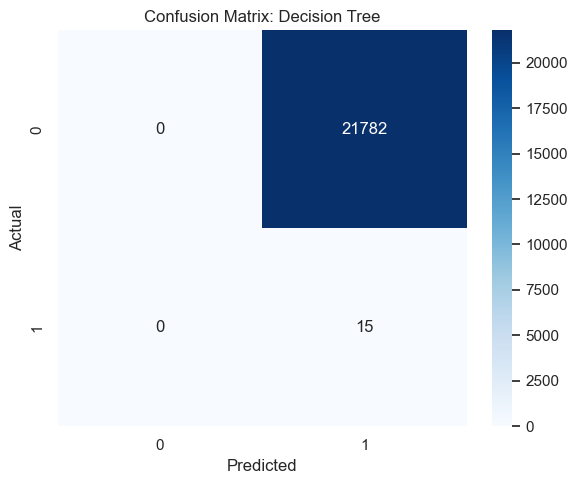

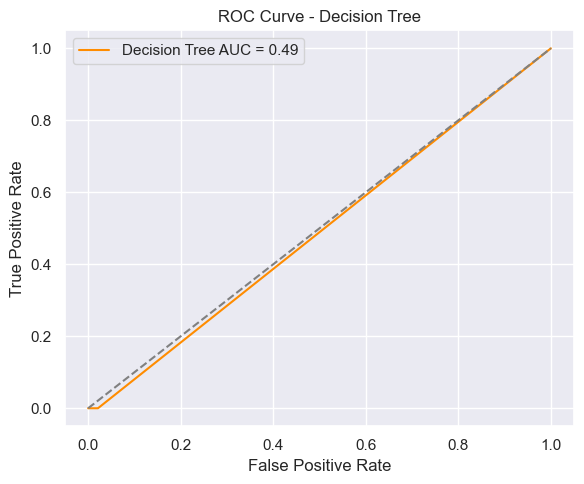

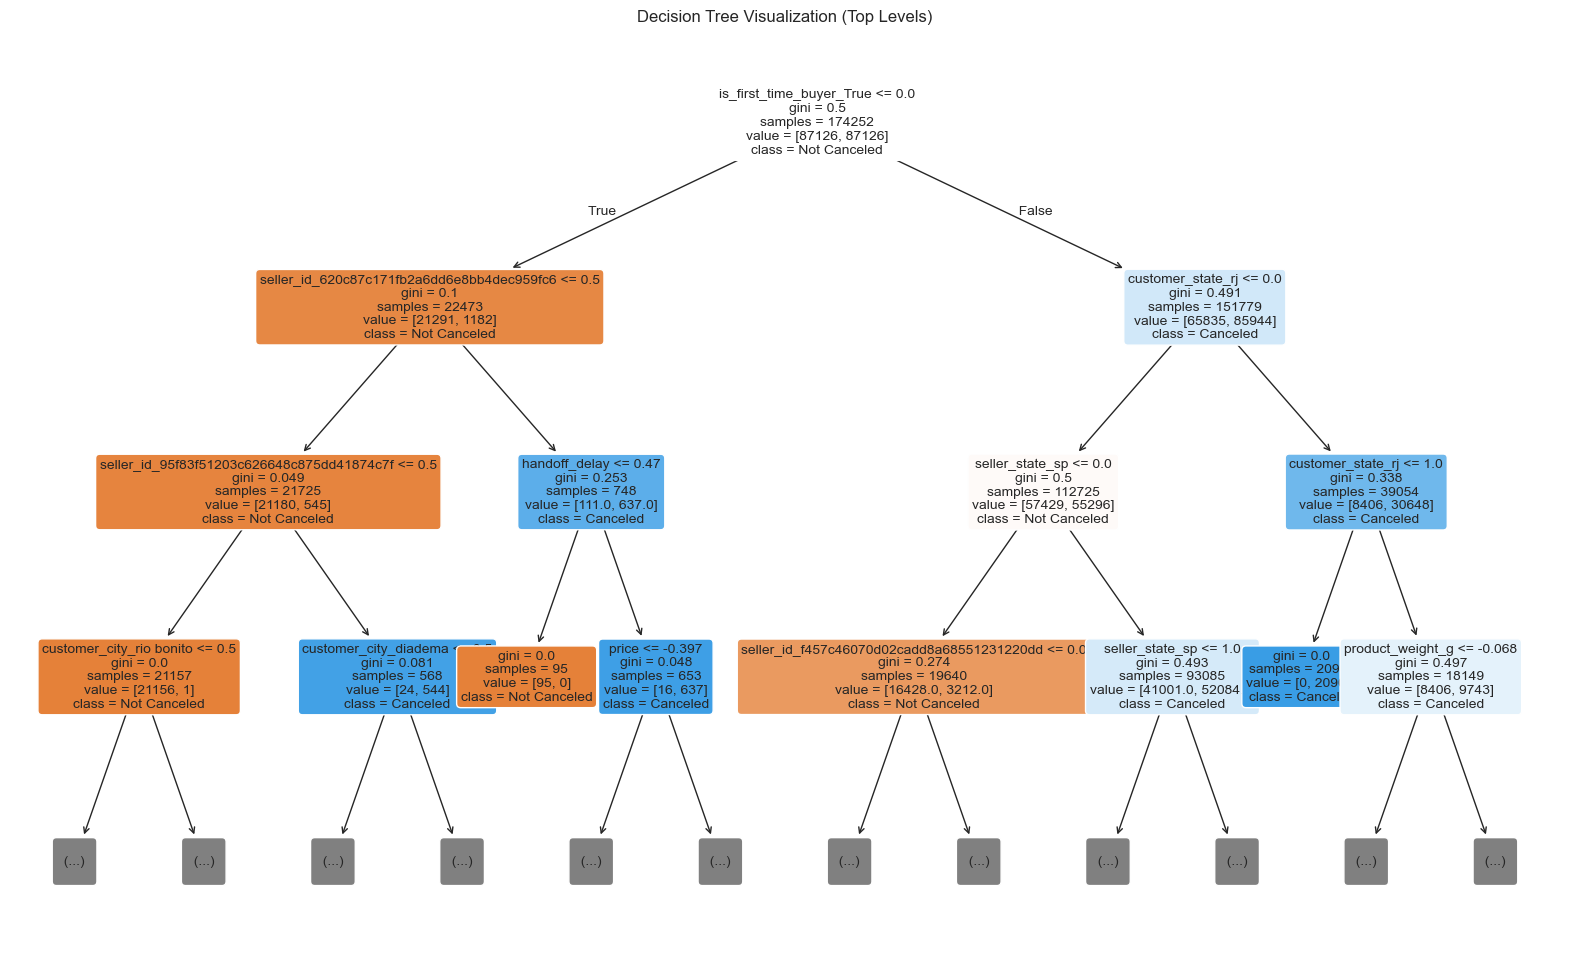

In [16]:
# Visualizing Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_tree_opt), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix: Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# ROC Curve
fpr_tree, tpr_tree, _ = roc_curve(y_test, y_proba_tree)
plt.figure(figsize=(6, 5))
plt.plot(fpr_tree, tpr_tree, label=f"Decision Tree AUC = {roc_auc_tree:.2f}", color='darkorange')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Decision Tree")
plt.legend()
plt.tight_layout()
plt.show()

# Visualizing the Decision Tree
plt.figure(figsize=(20, 12))
plot_tree(
    best_tree,
    feature_names=all_feature_names,
    class_names=['Not Canceled', 'Canceled'],
    filled=True,
    rounded=True,
    fontsize=10,
    max_depth=3  # limit depth for readability, remove or increase to see more
)
plt.title("Decision Tree Visualization (Top Levels)")
plt.show()

In [17]:
# **Random Forest**
# **Creating the Best Model**
# Random Forest
rf_clf = RandomForestClassifier(random_state=42)

param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [10, 15],
    'min_samples_split': [10, 20],
    'class_weight': ['balanced']  # Helps handle imbalance without SMOTE here, but still okay if you keep SMOTE
}

grid_rf = GridSearchCV(
                        estimator=rf_clf,
                        param_grid=param_grid_rf,
                        scoring=recall_scorer,
                        cv=stratified_cv,
                        verbose=2,
                        n_jobs=1
                    )

grid_rf.fit(X_train_resampled, y_train_resampled)
best_rf = grid_rf.best_estimator_
print("Best Parameters (Random Forest):", grid_rf.best_params_)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
[CV] END class_weight=balanced, max_depth=10, min_samples_split=10, n_estimators=100; total time=  39.0s
[CV] END class_weight=balanced, max_depth=10, min_samples_split=10, n_estimators=100; total time=  36.8s
[CV] END class_weight=balanced, max_depth=10, min_samples_split=10, n_estimators=100; total time=  41.1s
[CV] END class_weight=balanced, max_depth=10, min_samples_split=10, n_estimators=100; total time=  35.8s
[CV] END class_weight=balanced, max_depth=10, min_samples_split=10, n_estimators=100; total time=  37.6s
[CV] END class_weight=balanced, max_depth=10, min_samples_split=10, n_estimators=200; total time=  53.0s
[CV] END class_weight=balanced, max_depth=10, min_samples_split=10, n_estimators=200; total time=  59.5s
[CV] END class_weight=balanced, max_depth=10, min_samples_split=10, n_estimators=200; total time=  57.1s
[CV] END class_weight=balanced, max_depth=10, min_samples_split=10, n_estimators=200; total time=  5


Optimal Threshold (Random Forest): 0.4895

Classification Report (Random Forest):
              precision    recall  f1-score   support

       False       1.00      1.00      1.00     21782
        True       0.02      0.07      0.03        15

    accuracy                           1.00     21797
   macro avg       0.51      0.53      0.51     21797
weighted avg       1.00      1.00      1.00     21797

ROC-AUC Score (Random Forest): 0.6449


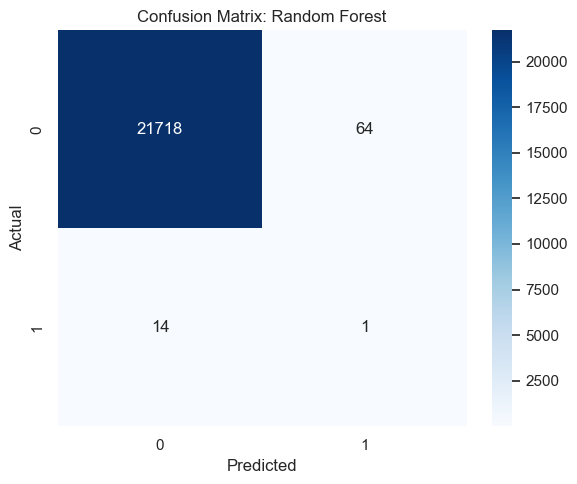

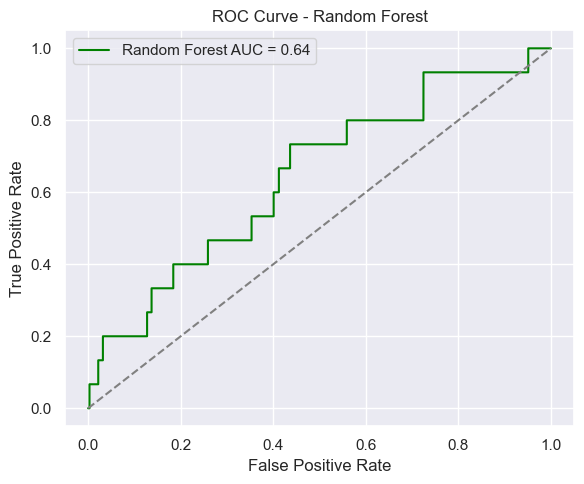

In [18]:
# **Evaluating the Model**
# Predict probabilities
y_proba_rf = best_rf.predict_proba(X_test_df)[:, 1]

# === Threshold Optimization ===
precision_rf, recall_rf, thresholds_rf = precision_recall_curve(y_test, y_proba_rf)
f2_scores_rf = 5 * (precision_rf * recall_rf) / (4 * precision_rf + recall_rf + 1e-6)
optimal_threshold_rf = thresholds_rf[np.argmax(f2_scores_rf)]
print(f"\nOptimal Threshold (Random Forest): {optimal_threshold_rf:.4f}")

# Apply optimal threshold
y_pred_rf_opt = (y_proba_rf >= optimal_threshold_rf).astype(int)

# Metrics
print("\nClassification Report (Random Forest):")
print(classification_report(y_test, y_pred_rf_opt))

roc_auc_rf = roc_auc_score(y_test, y_proba_rf)
print(f"ROC-AUC Score (Random Forest): {roc_auc_rf:.4f}")

plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_rf_opt), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix: Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
plt.figure(figsize=(6, 5))
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest AUC = {roc_auc_rf:.2f}", color='green')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.tight_layout()
plt.show()

In [20]:
# **XGBoost**
# **Creating the Model**
xgb_clf = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
param_grid_xgb = {
    'n_estimators': [100, 150],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0]
}

grid_xgb = GridSearchCV(
                        estimator=xgb_clf,
                        param_grid=param_grid_xgb,
                        scoring=recall_scorer,
                        cv=stratified_cv,
                        verbose=2,
                        n_jobs=1
                        )

grid_xgb.fit(X_train_resampled, y_train_resampled)
best_xgb = grid_xgb.best_estimator_
print("Best Parameters (XGBoost):", grid_xgb.best_params_)

Fitting 5 folds for each of 36 candidates, totalling 180 fits


/Users/alfonsoqu/anaconda3/lib/python3.11/site-packages/xgboost/training.py:183: UserWarning: [13:21:58] WARNING: /var/folders/k1/30mswbxs7r1g6zwn8y4fyt500000gp/T/abs_abwcuua5oq/croot/xgboost-split_1749630928197/work/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.8; total time=  42.6s


/Users/alfonsoqu/anaconda3/lib/python3.11/site-packages/xgboost/training.py:183: UserWarning: [13:22:47] WARNING: /var/folders/k1/30mswbxs7r1g6zwn8y4fyt500000gp/T/abs_abwcuua5oq/croot/xgboost-split_1749630928197/work/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.8; total time=  51.9s


...

[CV] END learning_rate=0.2, max_depth=7, n_estimators=150, subsample=1.0; total time=  58.2s


/Users/alfonsoqu/anaconda3/lib/python3.11/site-packages/xgboost/training.py:183: UserWarning: [16:16:02] WARNING: /var/folders/k1/30mswbxs7r1g6zwn8y4fyt500000gp/T/abs_abwcuua5oq/croot/xgboost-split_1749630928197/work/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END learning_rate=0.2, max_depth=7, n_estimators=150, subsample=1.0; total time=  58.6s


/Users/alfonsoqu/anaconda3/lib/python3.11/site-packages/xgboost/training.py:183: UserWarning: [16:16:57] WARNING: /var/folders/k1/30mswbxs7r1g6zwn8y4fyt500000gp/T/abs_abwcuua5oq/croot/xgboost-split_1749630928197/work/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best Parameters (XGBoost): {'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 150, 'subsample': 1.0}


In [21]:
# **Evaluating the Model**
# Predict probabilities
y_proba_xgb = best_xgb.predict_proba(X_test_df)[:, 1]

# Threshold Optimization
precision_xgb, recall_xgb, thresholds_xgb = precision_recall_curve(y_test, y_proba_xgb)
f2_scores_xgb = 5 * (precision_xgb * recall_xgb) / (4 * precision_xgb + recall_xgb + 1e-6)
optimal_threshold_xgb = thresholds_xgb[np.argmax(f2_scores_xgb)]
print(f"\nOptimal Threshold (XGBoost): {optimal_threshold_xgb:.4f}")

# Apply threshold
y_pred_xgb_opt = (y_proba_xgb >= optimal_threshold_xgb).astype(int)


Optimal Threshold (XGBoost): 0.0028



Classification Report (XGBoost):
              precision    recall  f1-score   support

       False       1.00      0.97      0.99     21782
        True       0.00      0.13      0.01        15

    accuracy                           0.97     21797
   macro avg       0.50      0.55      0.50     21797
weighted avg       1.00      0.97      0.98     21797

ROC-AUC Score (XGBoost): 0.5715


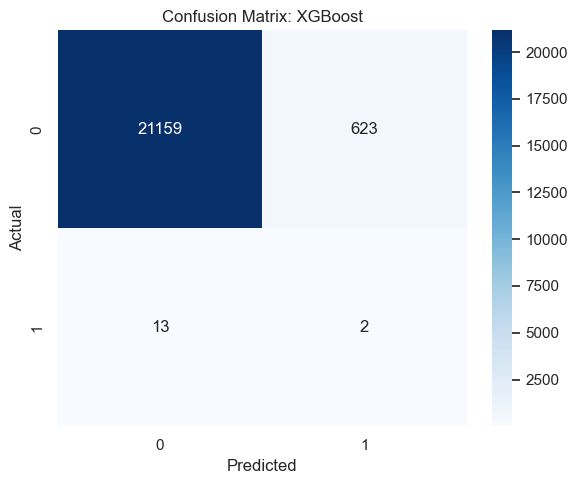

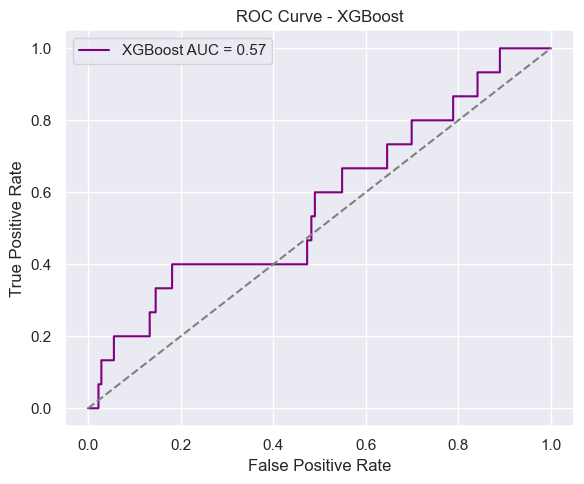

In [22]:
# Metrics
print("\nClassification Report (XGBoost):")
print(classification_report(y_test, y_pred_xgb_opt))

roc_auc_xgb = roc_auc_score(y_test, y_proba_xgb)
print(f"ROC-AUC Score (XGBoost): {roc_auc_xgb:.4f}")

plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_xgb_opt), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix: XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_proba_xgb)
plt.figure(figsize=(6, 5))
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost AUC = {roc_auc_xgb:.2f}", color='purple')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost")
plt.legend()
plt.tight_layout()
plt.show()

In [23]:
# **ANN**
# **Creating the Model**
# Define the ANN model
def create_complex_ann():
    model = Sequential([
        Dense(256, activation='relu', input_shape=(X_train_resampled.shape[1],)),
        BatchNormalization(),
        Dropout(0.4),
        Dense(128, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        Dense(64, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])
    focal_loss = BinaryFocalCrossentropy(gamma=2.0)
    model.compile(optimizer=Adam(learning_rate=0.001), loss=focal_loss, metrics=['Recall'])
    return model

# Wrap in KerasClassifier for calibration
keras_clf = KerasClassifier(model=create_complex_ann, epochs=15, batch_size=32, verbose=2)
keras_clf.fit(X_train_resampled, y_train_resampled)

/Users/alfonsoqu/anaconda3/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
5446/5446 - 26s - 5ms/step - Recall: 0.9820 - loss: 0.0177
Epoch 2/15
5446/5446 - 25s - 5ms/step - Recall: 0.9945 - loss: 0.0065
Epoch 3/15
5446/5446 - 26s - 5ms/step - Recall: 0.9964 - loss: 0.0049
Epoch 4/15
5446/5446 - 25s - 5ms/step - Recall: 0.9969 - loss: 0.0039
Epoch 5/15
5446/5446 - 24s - 4ms/step - Recall: 0.9977 - loss: 0.0033
Epoch 6/15
5446/5446 - 22s - 4ms/step - Recall: 0.9983 - loss: 0.0027
Epoch 7/15
5446/5446 - 23s - 4ms/step - Recall: 0.9982 - loss: 0.0029
Epoch 8/15
5446/5446 - 23s - 4ms/step - Recall: 0.9984 - loss: 0.0022
Epoch 9/15
5446/5446 - 24s - 4ms/step - Recall: 0.9987 - loss: 0.0022
Epoch 10/15
5446/5446 - 24s - 4ms/step - Recall: 0.9990 - loss: 0.0018
Epoch 11/15
5446/5446 - 22s - 4ms/step - Recall: 0.9990 - loss: 0.0020
Epoch 12/15
5446/5446 - 23s - 4ms/step - Recall: 0.9991 - loss: 0.0019
Epoch 13/15
5446/5446 - 23s - 4ms/step - Recall: 0.9993 - loss: 0.0016
Epoch 14/15
5446/5446 - 23s - 4ms/step - Recall: 0.9993 - loss: 0.0012
Epoch 15/15
544

KerasClassifier(
	model=<function create_complex_ann at 0x32296e980>
	build_fn=None
	warm_start=False
	random_state=None
	optimizer=rmsprop
	loss=None
	metrics=None
	batch_size=32
	validation_batch_size=None
	verbose=2
	callbacks=None
	validation_split=0.0
	shuffle=True
	run_eagerly=False
	epochs=15
	class_weight=None
)

In [24]:
# **Evaluating the Model**
# Predict probabilities
y_proba_ann = keras_clf.predict_proba(X_test_df)[:, 1]

# Threshold Optimization
precision_ann, recall_ann, thresholds_ann = precision_recall_curve(y_test, y_proba_ann)
f2_scores_ann = 5 * (precision_ann * recall_ann) / (4 * precision_ann + recall_ann + 1e-6)
optimal_threshold_ann = thresholds_ann[np.argmax(f2_scores_ann)]
print(f"\nOptimal Threshold (ANN): {optimal_threshold_ann:.4f}")

# Apply threshold
y_pred_ann_opt = (y_proba_ann >= optimal_threshold_ann).astype(int)

682/682 - 1s - 904us/step

Optimal Threshold (ANN): 0.0362



Classification Report (ANN):
              precision    recall  f1-score   support

       False       1.00      0.97      0.98     21782
        True       0.00      0.07      0.00        15

    accuracy                           0.97     21797
   macro avg       0.50      0.52      0.49     21797
weighted avg       1.00      0.97      0.98     21797

ROC-AUC Score (ANN): 0.5309


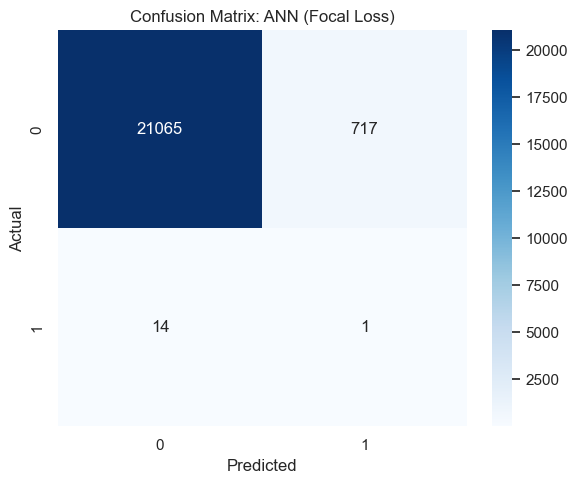

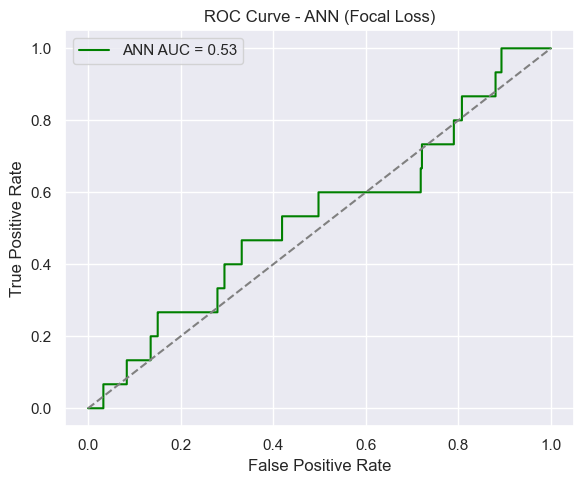

In [25]:
# Metrics
print("\nClassification Report (ANN):")
print(classification_report(y_test, y_pred_ann_opt))

roc_auc_ann = roc_auc_score(y_test, y_proba_ann)
print(f"ROC-AUC Score (ANN): {roc_auc_ann:.4f}")

# Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_ann_opt), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix: ANN (Focal Loss)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# ROC Curve
fpr_ann, tpr_ann, _ = roc_curve(y_test, y_proba_ann)
plt.figure(figsize=(6, 5))
plt.plot(fpr_ann, tpr_ann, label=f"ANN AUC = {roc_auc_ann:.2f}", color='green')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - ANN (Focal Loss)")
plt.legend()
plt.tight_layout()
plt.show()

In [26]:
# **Customer Segmentation Analysis**
# Analyze cancellation behavior by customer segments
print("=== CUSTOMER SEGMENTATION ANALYSIS ===")

# Analyze cancellation rates by first-time vs repeat buyers
segmentation_analysis = data_processed.groupby('is_first_time_buyer')['is_canceled'].agg(['count', 'sum', 'mean']).round(4)
segmentation_analysis.columns = ['Total_Orders', 'Canceled_Orders', 'Cancellation_Rate']
print("\nCancellation Analysis by Customer Type:")
print(segmentation_analysis)

# Analyze by region (state)
region_analysis = data_processed.groupby('customer_state')['is_canceled'].agg(['count', 'sum', 'mean']).round(4)
region_analysis.columns = ['Total_Orders', 'Canceled_Orders', 'Cancellation_Rate']
region_analysis = region_analysis.sort_values('Cancellation_Rate', ascending=False)
print("\nTop 10 States by Cancellation Rate:")
print(region_analysis.head(10))

# Statistical test for difference between first-time and repeat buyers
from scipy.stats import chi2_contingency

contingency_table = pd.crosstab(data_processed['is_first_time_buyer'], data_processed['is_canceled'])
chi2, p_value, dof, expected = chi2_contingency(contingency_table)
print(f"\nChi-square test for independence:")
print(f"Chi-square statistic: {chi2:.4f}")
print(f"P-value: {p_value:.4f}")
print(f"Degrees of freedom: {dof}")

# **Model Comparison**
# **Classification Reports**
print("Classification Report - Logistic Regression")
print(classification_report(y_test, y_pred_logreg_opt))

print("\nClassification Report - Decision Tree")
print(classification_report(y_test, y_pred_tree_opt))

print("\nClassification Report - Random Forest")
print(classification_report(y_test, y_pred_rf_opt))

print("\nClassification Report - XGBoost")
print(classification_report(y_test, y_pred_xgb_opt))

print("\nClassification Report - ANN")
print(classification_report(y_test, y_pred_ann_opt))

=== CUSTOMER SEGMENTATION ANALYSIS ===

Cancellation Analysis by Customer Type:
                     Total_Orders  Canceled_Orders  Cancellation_Rate
is_first_time_buyer                                                  
False                       26580                7             0.0003
True                        82403               68             0.0008

Top 10 States by Cancellation Rate:
                Total_Orders  Canceled_Orders  Cancellation_Rate
customer_state                                                  
to                       298                1             0.0034
pi                       510                1             0.0020
ma                       787                1             0.0013
rj                     14128               19             0.0013
mt                      1021                1             0.0010
pa                      1033                1             0.0010
es                      2204                2             0.0009
ba                

/Users/alfonsoqu/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/alfonsoqu/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/alfonsoqu/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [27]:
# **General Comparison**
def compute_f2(y_true, y_pred):
    return fbeta_score(y_true, y_pred, beta=2)

model_results = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest", "XGBoost", "ANN"],
    "F2 Score": [
        compute_f2(y_test, y_pred_logreg_opt),
        compute_f2(y_test, y_pred_tree_opt),
        compute_f2(y_test, y_pred_rf_opt),
        compute_f2(y_test, y_pred_xgb_opt),
        compute_f2(y_test, y_pred_ann_opt)
    ],
    "Recall": [
        recall_score(y_test, y_pred_logreg_opt),
        recall_score(y_test, y_pred_tree_opt),
        recall_score(y_test, y_pred_rf_opt),
        recall_score(y_test, y_pred_xgb_opt),
        recall_score(y_test, y_pred_ann_opt)
    ],
    "ROC AUC": [
        roc_auc,
        roc_auc_tree,
        roc_auc_rf,
        roc_auc_xgb,
        roc_auc_ann
    ]
})

display(model_results.sort_values(by="F2 Score", ascending=False).reset_index(drop=True))

,Model,F2 Score,Recall,ROC AUC
0,Random Forest,0.040000,0.066667,0.644915
1,Logistic Regression,0.037313,0.133333,0.666324
2,XGBoost,0.014599,0.133333,0.571530
3,ANN,0.006427,0.066667,0.530882
4,Decision Tree,0.003431,1.000000,0.489372


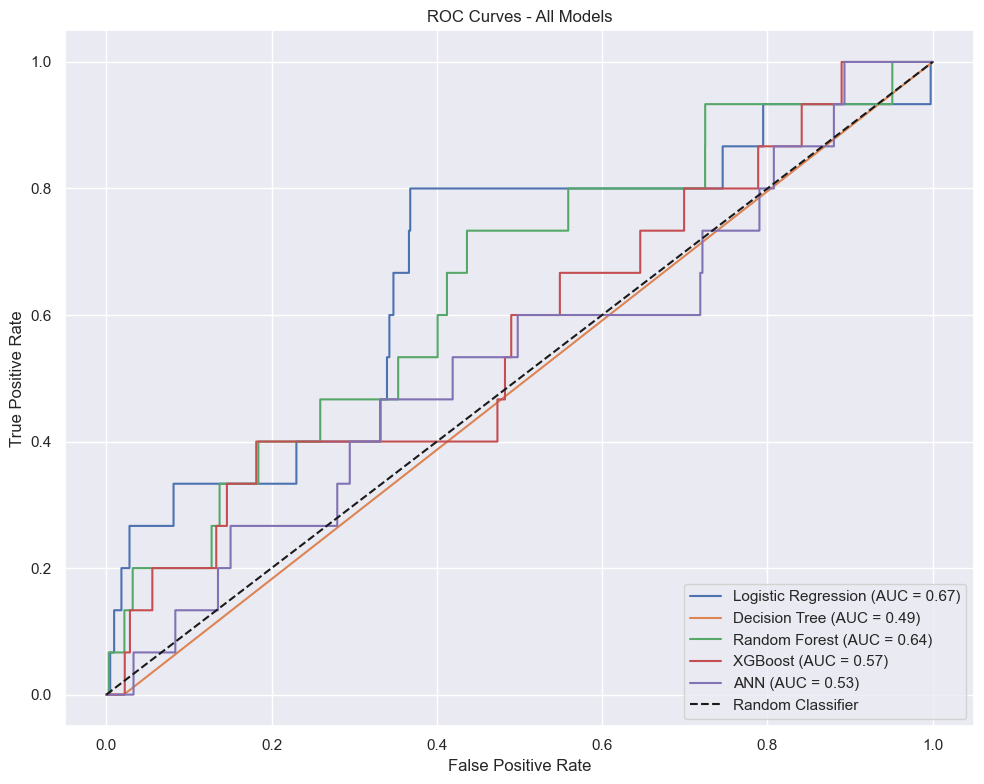

In [28]:
# **ROC Curve Comparison**
# Compute ROC curve data for each model
roc_data = []

# Logistic Regression
fpr, tpr, _ = roc_curve(y_test, y_proba_logreg)
roc_data.append(("Logistic Regression", fpr, tpr, roc_auc))

# Decision Tree
fpr, tpr, _ = roc_curve(y_test, y_proba_tree)
roc_data.append(("Decision Tree", fpr, tpr, roc_auc_tree))

# Random Forest
fpr, tpr, _ = roc_curve(y_test, y_proba_rf)
roc_data.append(("Random Forest", fpr, tpr, roc_auc_rf))

# XGBoost
fpr, tpr, _ = roc_curve(y_test, y_proba_xgb)
roc_data.append(("XGBoost", fpr, tpr, roc_auc_xgb))

# ANN
fpr, tpr, _ = roc_curve(y_test, y_proba_ann)
roc_data.append(("ANN", fpr, tpr, roc_auc_ann))

# Plot
plt.figure(figsize=(10, 8))
for name, fpr, tpr, auc_score in roc_data:
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.2f})")

plt.plot([0, 1], [0, 1], 'k--', label="Random Classifier")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - All Models')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

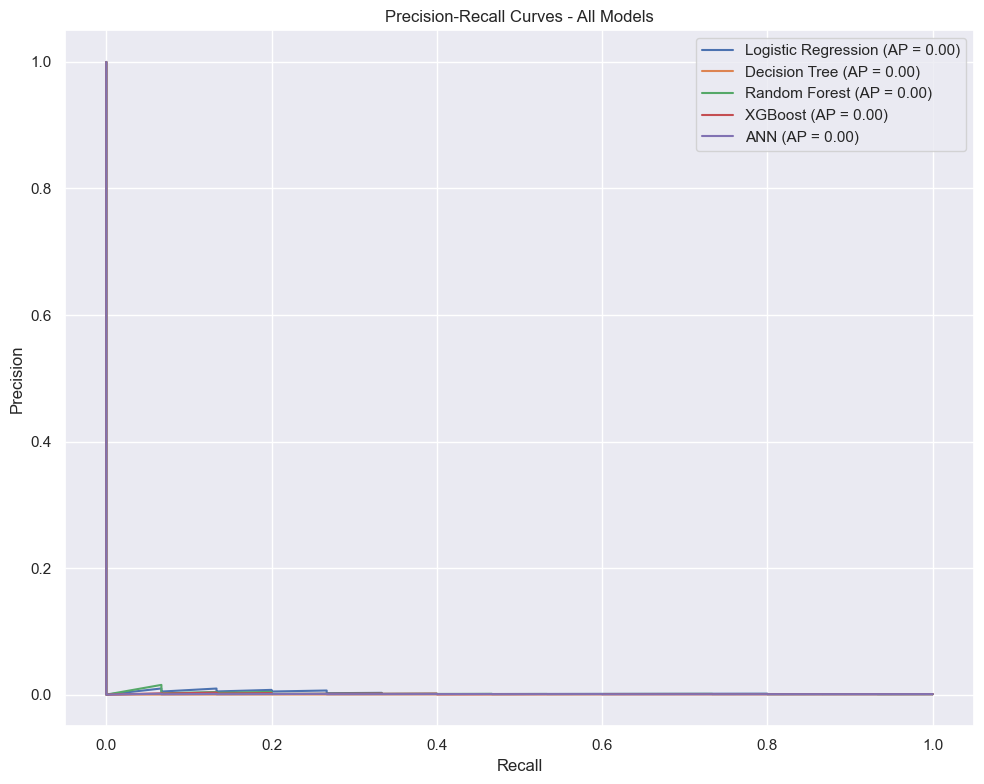

In [29]:
# **Precision Recall Curve**
# Compute Precision-Recall curve data
pr_data = []

# Logistic Regression
precision, recall, _ = precision_recall_curve(y_test, y_proba_logreg)
ap_logreg = average_precision_score(y_test, y_proba_logreg)
pr_data.append(("Logistic Regression", precision, recall, ap_logreg))

# Decision Tree
precision, recall, _ = precision_recall_curve(y_test, y_proba_tree)
ap_tree = average_precision_score(y_test, y_proba_tree)
pr_data.append(("Decision Tree", precision, recall, ap_tree))

# Random Forest
precision, recall, _ = precision_recall_curve(y_test, y_proba_rf)
ap_rf = average_precision_score(y_test, y_proba_rf)
pr_data.append(("Random Forest", precision, recall, ap_rf))

# XGBoost
precision, recall, _ = precision_recall_curve(y_test, y_proba_xgb)
ap_xgb = average_precision_score(y_test, y_proba_xgb)
pr_data.append(("XGBoost", precision, recall, ap_xgb))

# ANN
precision, recall, _ = precision_recall_curve(y_test, y_proba_ann)
ap_ann = average_precision_score(y_test, y_proba_ann)
pr_data.append(("ANN", precision, recall, ap_ann))

# Plot
plt.figure(figsize=(10, 8))
for name, precision, recall, ap_score in pr_data:
    plt.plot(recall, precision, label=f"{name} (AP = {ap_score:.2f})")

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves - All Models')
plt.legend(loc='upper right')
plt.grid(True)
plt.tight_layout()
plt.show()